## Setup

In [1]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import geopandas as gpd
import shapely
import contextily as ctx

# import kml reading and set supported driver
import fiona
fiona.drvsupport.supported_drivers["KML"] = "rw"

In [3]:
from gridsample.utils import create_ids, save_shapefiles

In [4]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data_india"
RAW_DATA_DIR = DATA_DIR / "00_raw"
INPUT_DATA_DIR = DATA_DIR / "01_processed"

## Load region shapes

In [5]:
colony_gdf = gpd.read_file(
    RAW_DATA_DIR / "colony_shapes" / "colony_shapes.kml",
    crs="4326",
    driver="KML",
).drop(columns=["Description"])

In [6]:
# remove z-dimension from shapes
colony_gdf.geometry = colony_gdf.geometry.apply(lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2)))

In [7]:
colony_gdf

,Name,geometry
0,Golden City,"POLYGON ((77.47085 23.17110, 77.47048 23.17249..."


## Rooftops

In [8]:
from s2cell.s2cell import lat_lon_to_cell_id
import boto3

### Download rooftop data

Get the ID of the level 6 S2 Cell that this colony sits inside

In [9]:
s2_cell_id = lat_lon_to_cell_id(lat=colony_gdf.centroid.y, lon=colony_gdf.centroid.x, level=6)
s2_cell_id

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_84929/3190238580.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_cell_id = lat_lon_to_cell_id(lat=colony_gdf.centroid.y, lon=colony_gdf.centroid.x, level=6)
/Users/amiremami/miniconda3/envs/gridsample/lib/python3.11/site-packages/s2cell/s2cell.py:649: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lat_rad = math.radians(lat)
/Users/amiremami/miniconda3/envs/gridsample/lib/python3.11/site-packages/s2cell/s2cell.py:650: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lon_rad = math.radians(lon)


4142467232250724352


Download closest S2 cell shapefile from https://beta.source.coop/vida/google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/

In [10]:
s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"

if s2_rooftops_path.exists():
    print("File already exists")
else:
    s3 = boto3.client("s3", endpoint_url="https://data.source.coop")
    s3.download_file(
        "vida",
        f"google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/{s2_cell_id}.parquet",
        str(s2_rooftops_path),
    )
    print("File downloaded.")

File already exists


### Load and process rooftop data

<Axes: >

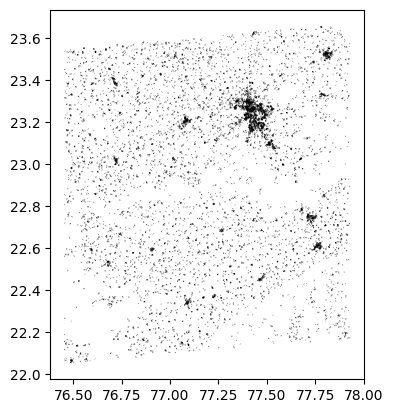

In [ ]:
rooftop_gdf = gpd.read_parquet(s2_rooftops_path)
rooftop_gdf.sample(10000).plot(edgecolor="k")

In [12]:
rooftop_gdf = rooftop_gdf.drop(columns=["boundary_id", "s2_id", "geohash", "bbox", "country_iso"])

In [13]:
rooftop_gdf["rooftop_id"] = create_ids(len(rooftop_gdf), f"ROOFTOP_S2_{s2_cell_id}_")

In [14]:
rooftop_gdf

,bf_source,confidence,area_in_meters,geometry,rooftop_id
1312452,google,0.7285,23.7821,"POLYGON ((76.46367 22.05372, 76.46362 22.05372...",ROOFTOP_S2_4142467232250724352_0000001
1515388,google,0.7153,9.8125,"POLYGON ((76.46483 22.05428, 76.46483 22.05432...",ROOFTOP_S2_4142467232250724352_0000002
1710778,google,0.7004,7.0812,"POLYGON ((76.45724 22.05924, 76.45724 22.05927...",ROOFTOP_S2_4142467232250724352_0000003
1252889,microsoft,NaN,68.3447,"POLYGON ((76.45754 22.06020, 76.45746 22.06020...",ROOFTOP_S2_4142467232250724352_0000004
1251238,microsoft,NaN,40.9520,"POLYGON ((76.46078 22.05540, 76.46086 22.05541...",ROOFTOP_S2_4142467232250724352_0000005
...,...,...,...,...,...
566629,microsoft,NaN,25.4265,"POLYGON ((77.91525 23.66157, 77.91520 23.66158...",ROOFTOP_S2_4142467232250724352_2793461
567977,google,0.7441,29.2368,"POLYGON ((77.91905 23.66114, 77.91899 23.66116...",ROOFTOP_S2_4142467232250724352_2793462
567059,google,0.8234,159.8137,"POLYGON ((77.91913 23.66124, 77.91902 23.66128...",ROOFTOP_S2_4142467232250724352_2793463
566685,microsoft,NaN,25.7559,"POLYGON ((77.91606 23.66377, 77.91600 23.66377...",ROOFTOP_S2_4142467232250724352_2793464


### Match rooftops to colony

In [15]:
subset_rooftops_gdf = rooftop_gdf.sjoin(colony_gdf, how="inner", predicate="intersects")
subset_rooftops_gdf

,bf_source,confidence,area_in_meters,geometry,rooftop_id,index_right,Name
912838,google,0.6631,15.7373,"POLYGON ((77.47003 23.16701, 77.47001 23.16705...",ROOFTOP_S2_4142467232250724352_2015056,0,Golden City
686439,google,0.6634,10.3174,"POLYGON ((77.47002 23.16701, 77.47000 23.16700...",ROOFTOP_S2_4142467232250724352_2015057,0,Golden City
1185505,google,0.6713,15.7811,"POLYGON ((77.46996 23.16721, 77.46993 23.16725...",ROOFTOP_S2_4142467232250724352_2015059,0,Golden City
1022640,google,0.7871,104.3085,"POLYGON ((77.47011 23.16713, 77.47007 23.16720...",ROOFTOP_S2_4142467232250724352_2015060,0,Golden City
950556,google,0.8437,42.1019,"POLYGON ((77.47002 23.16721, 77.46999 23.16727...",ROOFTOP_S2_4142467232250724352_2015061,0,Golden City
...,...,...,...,...,...,...,...
786004,google,0.7369,81.3926,"POLYGON ((77.47056 23.17216, 77.47054 23.17222...",ROOFTOP_S2_4142467232250724352_2018318,0,Golden City
900295,google,0.8061,92.1362,"POLYGON ((77.47050 23.17207, 77.47049 23.17209...",ROOFTOP_S2_4142467232250724352_2018319,0,Golden City
1226640,google,0.7346,94.4702,"POLYGON ((77.47062 23.17206, 77.47060 23.17212...",ROOFTOP_S2_4142467232250724352_2018320,0,Golden City
1153984,google,0.7561,98.9044,"POLYGON ((77.47051 23.17238, 77.47050 23.17244...",ROOFTOP_S2_4142467232250724352_2018325,0,Golden City


In [17]:
save_shapefiles(
    subset_rooftops_gdf,
    INPUT_DATA_DIR,
    "golden_city_rooftops",
    formats=["parquet"],
)